# Week-2 Day-4

## Tasks


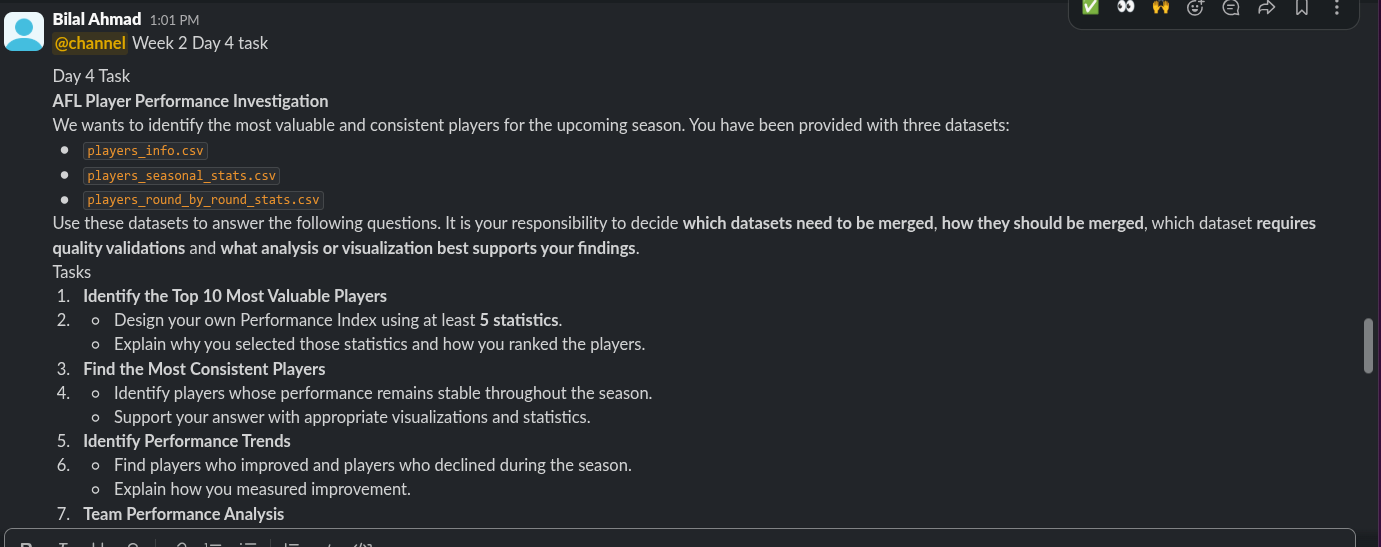

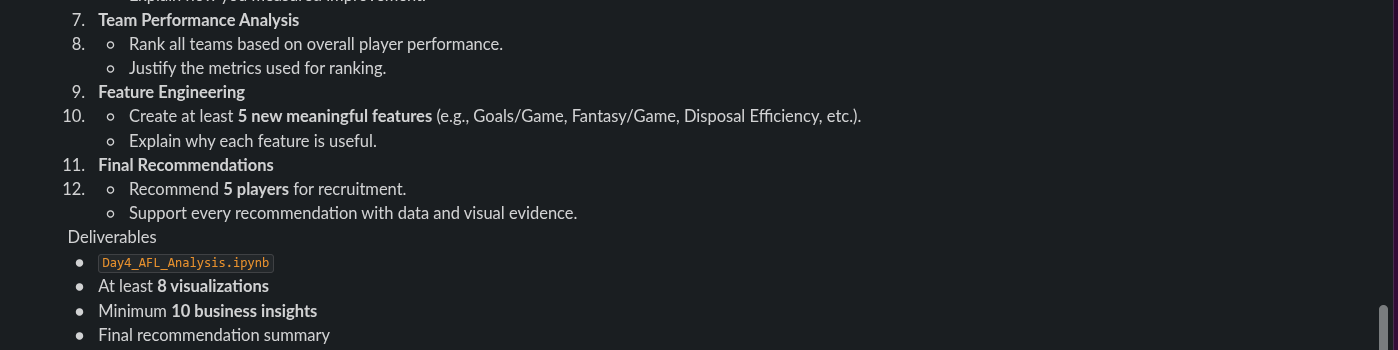

1. Identify the Top 10 Most Valuable Players
   1. Design a performance index of at least 5 statistics
   2. explain why each was selected
2. Find the Most Consistent Players
   1. Identify playesr whose performance remain stable and support your answer with visualizations and statistics
3. Identify Performance Trends
   1. find players who improved or declined in performance throughout the seasons
   2. explain how you measured improvment and decline
4. Team Performance Analysis
   1. Rank all Teams based on overall player performance
   2. justify the metrics you used for the ranking
5. Feature Engineering
   1. Create at least 5 new meaningful features (eg: goals/games, fantasy/games, disposals efficiency)
   2. explain why each new feature you engineered is useful
6. Final Recommendation
   1. Recommend 5 players for recruitment
   2. support every recommendation with data and visual evidence


**Note**: Have at least 8 total visualizations in the notebook and 10 business insights and a final recommendation summary 

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# again, make all the charts look nice
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.grid.axis"] = "x"
plt.rcParams["grid.alpha"] = 0.3

In [26]:
info_df = pd.read_csv("../Day-2/final/players_info.csv")
seasonal_df = pd.read_csv("../Day-2/final/seasonal_stats.csv")
round_df = pd.read_csv("../data/afl_players_round_by_round_stats_raw.csv")

In [27]:
# the task doesn't say to clean the round by round csv but I think it will cause trouble later if I don't check it properly right now
round_df.head()

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,NaN,48
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,NaN,NaN,NaN,NaN,NaN,45656,1994-08-13,81,NaN,45
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,45929,1997-05-31,32,NaN,-25


In [28]:
round_df.columns

Index(['id', 'team', 'year', 'career_game_count', 'opponent', 'round',
       'result', 'jersey_num', 'kicks', 'marks', 'handballs', 'disposals',
       'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s',
       'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against',
       'brownlow_votes', 'contested_possessions', 'uncontested_possessions',
       'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces',
       'goal_assist', 'percentage_of_game_played', 'player_id', 'match_date',
       'fantasy_points', 'score', 'margin'],
      dtype='str')

**Some Initial Findings**:

- Its quite clear that it has a lot of rows from the previous two datasets, I can actually just use player_id from here and merge it all and have it in one df
- Took a glance at the csv and looks like team names are already normalized in this one
- the amount of null values is insane, this will take forever to clean
- the first id column seems to be a normal unique identifier, will probably remove that just like I did with the previous two datasets, we don't need a separate id column in pandas


---

### Cleaning the Round by Round dataset

In [29]:
round_df.shape

(274089, 36)

In [30]:
round_df.isna().sum()

id                                0
team                              0
year                              0
career_game_count                 0
opponent                          0
round                             0
result                            0
jersey_num                        0
kicks                          1300
marks                          8051
handballs                      4433
disposals                      8453
goals                         74737
behinds                       81093
hit_outs                      96629
tackles                       28682
rebound_50s                   62856
inside_50s                    46574
clearances                    63919
clangers                      49965
free_kicks_for                53842
free_kicks_against            53275
brownlow_votes               110481
contested_possessions         38826
uncontested_possessions       37998
contested_marks               90677
marks_inside_50               91378
one_percenters              

In [31]:
round_df.duplicated().sum()

np.int64(10)

- ok, the total df has 274089 total records, and literally all of them are Null for the score column, weird. Could just drop score column or make up some random formula to find score. better to drop. Most of the other columns could be filled with zero just like I did before

In [32]:
# drop that useless score column
round_df = round_df.drop(columns=["score"])

# all columns that I gotta fill with zero
count_cols = [
    "kicks",
    "marks",
    "handballs",
    "disposals",
    "goals",
    "behinds",
    "hit_outs",
    "tackles",
    "rebound_50s",
    "inside_50s",
    "clearances",
    "clangers",
    "free_kicks_for",
    "free_kicks_against",
    "brownlow_votes",
    "contested_possessions",
    "uncontested_possessions",
    "contested_marks",
    "marks_inside_50",
    "one_percenters",
    "bounces",
    "goal_assist",
]

# done, filled with zero
round_df[count_cols] = round_df[count_cols].fillna(0)

# just ganna directly override disposals just like I did in the previous dataset too in case there are any wrong enteries
round_df["disposals"] = round_df["kicks"] + round_df["handballs"]

# ganna convert date to datetime
round_df["match_date"] = pd.to_datetime(round_df["match_date"])

# just ganna drop any full duplicate rows
round_df = round_df.drop_duplicates()

In [33]:
round_df.isna().sum()


id                               0
team                             0
year                             0
career_game_count                0
opponent                         0
round                            0
result                           0
jersey_num                       0
kicks                            0
marks                            0
handballs                        0
disposals                        0
goals                            0
behinds                          0
hit_outs                         0
tackles                          0
rebound_50s                      0
inside_50s                       0
clearances                       0
clangers                         0
free_kicks_for                   0
free_kicks_against               0
brownlow_votes                   0
contested_possessions            0
uncontested_possessions          0
contested_marks                  0
marks_inside_50                  0
one_percenters                   0
bounces             

In [34]:
round_df.duplicated().sum()

np.int64(0)

- this is clean now, left that percentage NULL intentionally just like I did with the previous dataset (not calculated by AFL before 2003, same reasoning as with the other dataset)

---
---
---

## 1. Identify the Top 10 Most Valuable Players
   1. Design a performance index of at least 5 statistics
   2. explain why each was selected

- First, we have to actually decide the 5 columns to use
  - the most obvious pick in my mind is fantasy points, they kinda have a mix of everything (previous EDA notebooks details the formula for fantasy points). It is an average of basically all the other valuable stats. So that is the fist pic
  - the second pick would be disposals, disposals is just kicks+handballs, so it basically evaluates to what extent a player was touching the ball, the more you were incontact with the ball, the more valuable you are, that is my logic at least. Someone who couldn't even get to the ball would obviously be less valuable
  - goals is a third obvious one to pick, this is self explanatory, more goals === BETTER. A player scoring more goals is obviously more valuable
    - ok, this is all I can think of on my own, Idk football so Idk which column would be most significant, will be back after asking AI and doing some research
  - ok, so according to claude, tackles basically show the "defensive contribution" of a player which is very important. The more tackles a player does, the more valuable he is, generally speaking. So tackles is my 4th stat
  - the last one will be contested_possesions, claude says its a proxy for winning the ball under pressure which is a big indicator of how valuable a player is


I think its also worth seeing which other columns I could have picked other than these 5, or in addition to these 5:

- I can see Mark in the df, Mark is simply catching a kicked ball, quite similar to kicks+handballls (disposals)
- hit_outs are completed skewed towards the ruckman (ruckmans are specialist, the tallest dude in the team basically)
- clearance is very biased towards midfilder players, they do the most clearances (clearance just means you got the ball at a stoppage, and stoppage just means that the game was paused by the umpire for some reason and started again)
- uncontested possession is a pretty bad metric too since its easy, its the opposite of "valuable", we should reward contest possessions (which we did, look at the 5th stat I chose)
- turnover is an interesting, its a negative stat, I can use it as a penalty. Turnover just means losing possession of the ball to the other team, so a high turnover is bad. I guess if we want to get more advanced then turnover can be used as a negative stat and if a player has high turnover then I can make him less valuable. For now, lets just go forward with the 5 stats I picked (well, I picked 3, claude picked the other 2)

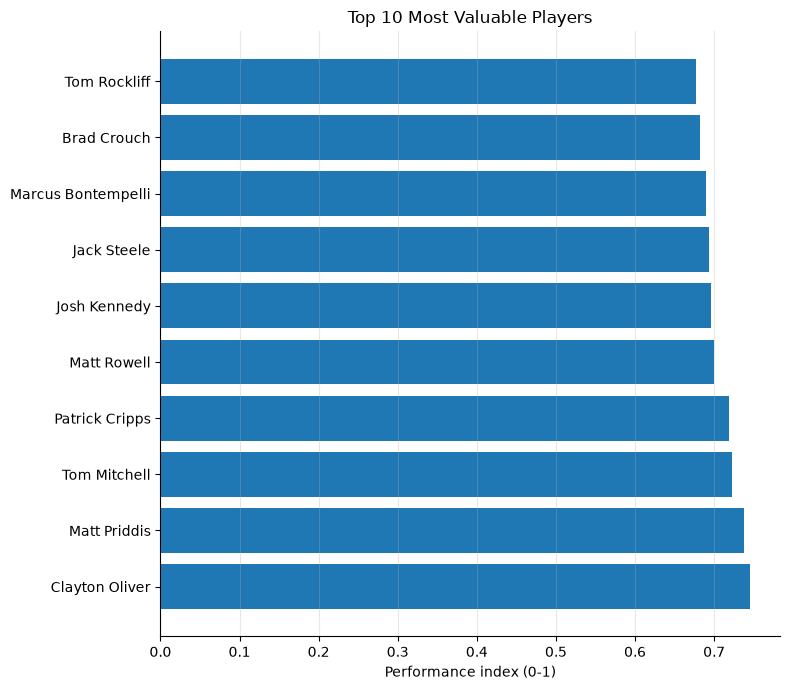

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# ok, going to average each player's stats, the 5 stats I just picked
player_stats = round_df.groupby("player_id").agg(
    games=("id", "count"),
    avg_fantasy_points=("fantasy_points", "mean"),
    avg_disposals=("disposals", "mean"),
    avg_goals=("goals", "mean"),
    avg_tackles=("tackles", "mean"),
    avg_contested_possessions=("contested_possessions", "mean"),
)

# this is the criteria now
stat_cols = ["avg_fantasy_points", "avg_disposals", "avg_goals", "avg_tackles", "avg_contested_possessions"]

# this was an AI suggestion and it makes sense, we are not doing wieighted scaling where one column matters more than the other so its best to actually normalize the values
scaler = MinMaxScaler()
normalized = scaler.fit_transform(player_stats[stat_cols])

# all 5 of those stats can be used to make one simple column, just mean of all (now I can use this column in the later questions too)
player_stats["performance_index"] = normalized.mean(axis=1)

# grab top 10 players
top10 = player_stats[player_stats["games"] >= 20].sort_values("performance_index", ascending=False).head(10)

# so we only have Ids in the round_df, we can get the names corresponding to each id from the info_df I think, dk the code so will just AI
names = info_df[["id", "name"]].set_index("id")["name"]
top10_named = top10.join(names)

# same plotting strategy as the last notebook, nothing fancy. btw I don't think a plot is even needed for this task but you guys said that I gotta have at least 8 plots so just ganna make lots of plots
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top10_named["name"], top10_named["performance_index"])
ax.set_xlabel("Performance index (0-1)")
ax.set_title("Top 10 Most Valuable Players")
plt.tight_layout()
plt.show()


- Ok, looks like Clayton Oliver is the best player according to my 5 stats, I guess thats good? right? Not sure, Idk how to validate this.
- I will ask claude to just pull out data regarding these players from the web and validate, here is the result from claude:

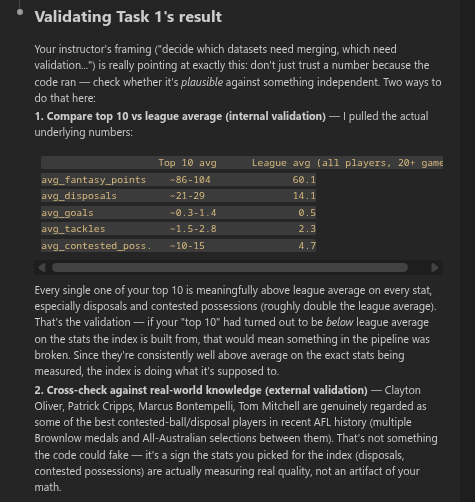


- I think that is good enough for validation

**Business Insights**:
- I don't think I can extract anything from this, except that the 5 stats I chose are actually valid and a pretty good estimate of a player being "Valuable"
- It is of note that Tony (the super outlier dude from the previous EDA) is not in my list of top 10, which is unexpected, but I think its valid, perhaps tony made the most goals but was not super good in the rest of the stats

---

## 2. Find the Most Consistent Players
   1. Identify players whose performance remain stable and support your answer with visualizations and statistics


ok, how do I find who is consistent? One thing the question doesn't specify is that do I have to answer whether a player consistently APPEARED in every session, or do we have to check how consistent his performance is

- if its the latter (consistent performance across sessions) then we can see standard deviation (how much the score swings above and below the mean) match to match, if its a lot, then the player is not consistent. This is probably a very simple way of doing this. Like, if there is a player whose score is close to 80 in every game, then obviously he is much more consistent than someone who has 80 in one game and 20 in the next
- Although, the question says "throughout the season", probably meant seasons. So, the question is simply does a player's yearly average stay steady across diff seasons, not just matches

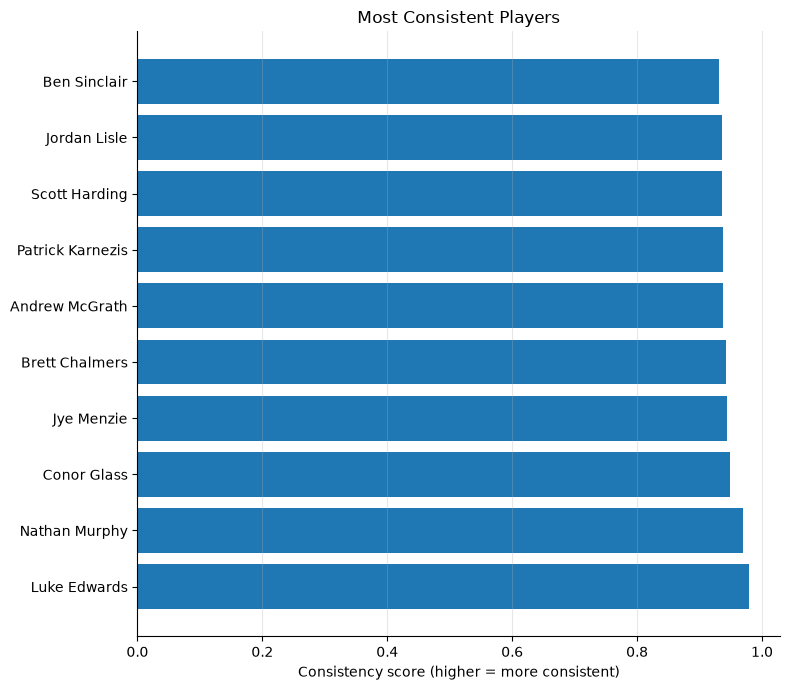

In [51]:
# ganna group by year to get one row per season
season_avg = round_df.groupby(["player_id", "year"])["fantasy_points"].mean().reset_index()

consistency = pd.DataFrame()
# get the mean
consistency["avg_season_fantasy"] = season_avg.groupby("player_id")["fantasy_points"].mean()
# get the std dev
consistency["std_season_fantasy"] = season_avg.groupby("player_id")["fantasy_points"].std()
# gotta know how many seasons of data we got per player
consistency["seasons"] = season_avg.groupby("player_id")["fantasy_points"].count()
# going to drop rows with players who played a very tiny amount of matches
consistency = consistency[consistency["seasons"] >= 4]
# the chart was hella hard to understand because it was inversed, ai said to do 1 - here to have a simple "higher is better" chart
consistency["consistency_score"] = 1 - (consistency["std_season_fantasy"] / consistency["avg_season_fantasy"])

most_consistent = consistency.sort_values("consistency_score", ascending=False).head(10).join(names)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(most_consistent["name"], most_consistent["consistency_score"])
ax.set_xlabel("Consistency score (higher = more consistent)")
ax.set_title("Most Consistent Players")
plt.tight_layout()
plt.show()


here is the inverse logic i just talked about in the comments

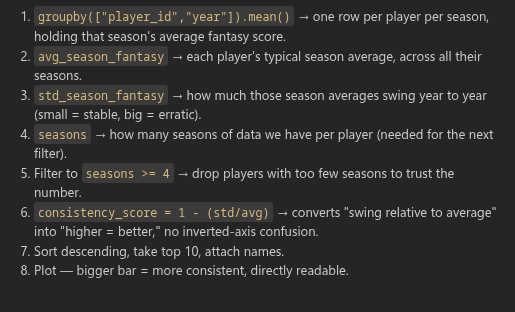

ok, this chart kinda makes sense, kinda doesn't

- I had imagined that the players from task 1 would come up here again because the "most valuable" players should also be the "most consistent" players, that was my assumption at least, either my logic is wrong or the chart is wrong

**Business Insights**:
- Most of these guys don't appear in the chart for task 1, meaning that consistent doesn't mean "most valuable". So consistency doesn't mean the player himself is actually good. A pretty bad player can get consistently average scores and be "very consistent" but his scores are still just average. So I guess its hard to be a Quality (valuable) player and still retain super good Quantity (consistency) as well
- This is not really early career noise (new player comes and scores really consistent for his first 4 seasons and leads the chart) since I only took those players with 4+ seasons

---

## 3. Identify Performance Trends
   1. find players who improved or declined in performance throughout the seasons
   2. explain how you measured improvment and decline


ok, did a player improve or not, Idk how to find this, but of course AI has my back, here is the idea:
- if the early career output is bad and the late career output is good then its easy to say the player has improved a ton
- the simple approach is take the first 2 years (seasons) as early, and take last 2 seasons of that player as late, 2 seasons each instead of 1 so 1 unusual performance doesn't become the deciding factor. if a player played a total of 4 season then just take that player out, it will be unfairly skewed in his favor otherwise (same logic as task 2)
- so, avg of last 2 seasons minus avg of first 2 seasons, the bigger the answer, the more the dude has improved.

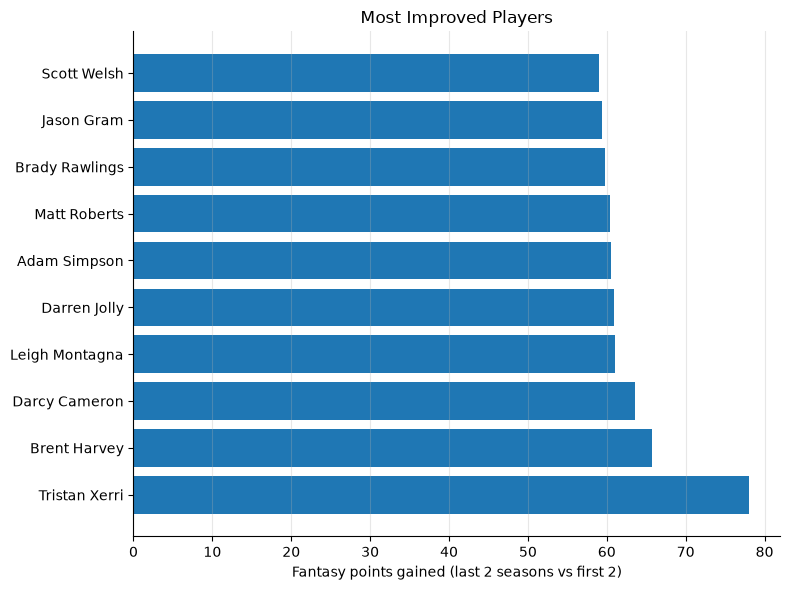

In [54]:
# groupby year and fantasy points again
season_avg = round_df.groupby(["player_id", "year"])["fantasy_points"].mean().reset_index()
# sort in ascending
season_avg = season_avg.sort_values("year")

# get total seasons the player played
season_counts = season_avg.groupby("player_id")["year"].transform("count")
# grab only players who played more or at least 4 seasons
season_avg = season_avg[season_counts >= 4]

# grab first 2
early_career = season_avg.groupby("player_id").head(2).groupby("player_id")["fantasy_points"].mean()
# grab last 2
late_career = season_avg.groupby("player_id").tail(2).groupby("player_id")["fantasy_points"].mean()
# the simple minus formula in the markdown cell above that I just talked about
improvement = (late_career - early_career).rename("improvement")
# sort in descending and get first 10 simply
most_improved = improvement.sort_values(ascending=False).head(10).to_frame().join(names)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(most_improved["name"], most_improved["improvement"])
ax.set_xlabel("Fantasy points gained (last 2 seasons vs first 2)")
ax.set_title("Most Improved Players")
plt.tight_layout()
plt.show()


**Business Insights**:
- Tristen has improved the most, lets just google Tristen Xerri and see what it says

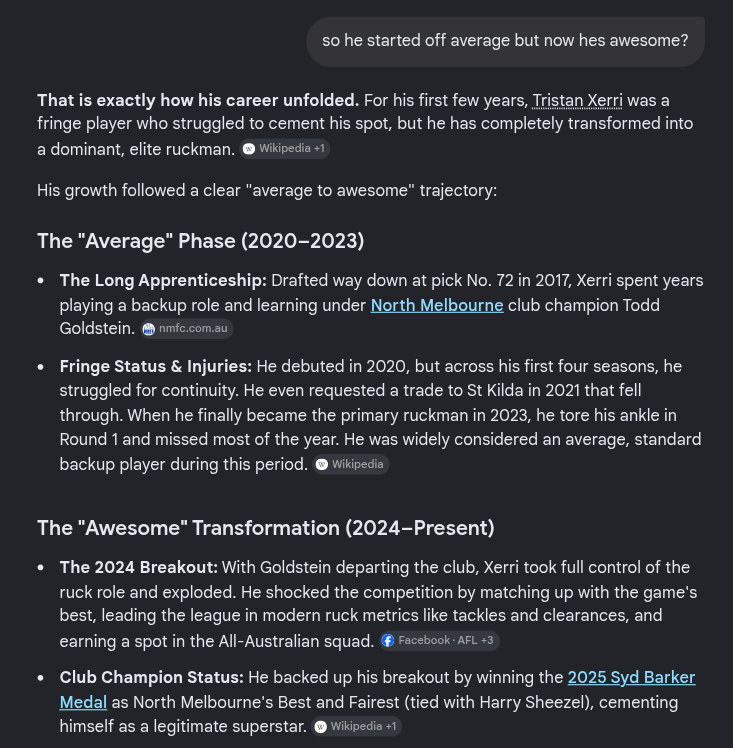


- well, I am happy with the evidence, awesome
- if we combine the previous task 2 chart and this one and find a player that has decent consistency and also is decently growing/improving then we we have a complete recruitment picture of who to recruit (a player who is consistently improving basically)

---

## 4. Team Performance Analysis
   1. Rank all Teams based on overall player performance
   2. justify the metrics you used for the ranking


I think I can use the performance index I made in task 1 here and get a quick answer easily.

- we can use the player_stats df from task 1, do a join of that with the round_df, foreign key will be player_id obviously, and groupby team, and then just print mean performance index. and hence we will end up with team level performance index instead of just single player, and whichever team has the best performance index, that team is ranked the highest. complicated logic, but I'm sure if I explain to claude then it can give the exact code to join the two df and do groupby team, I can't write that myself probably

- I think there is no point in inventing a completely new metric for the team performance, the performance index I made in task 1 works fine for this too

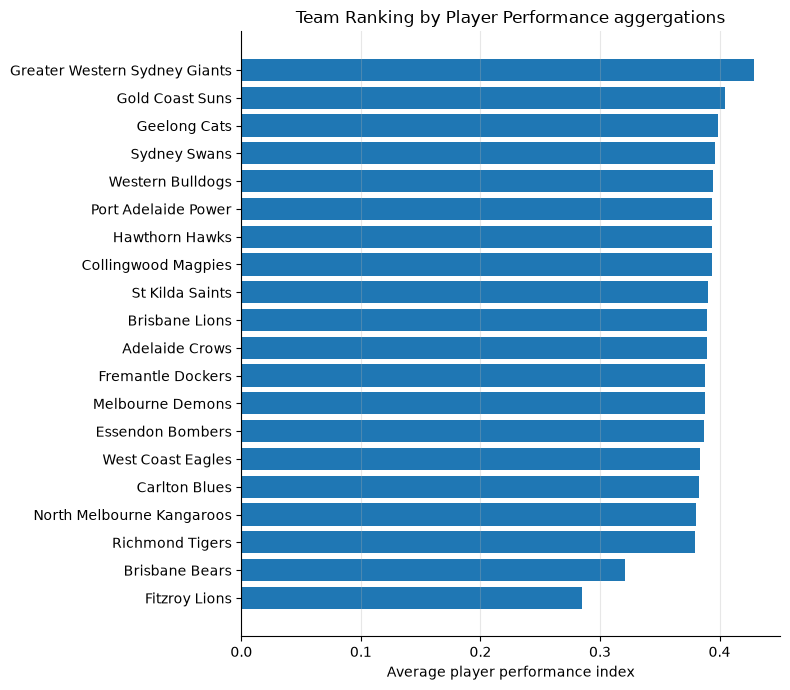

In [60]:
# ok, this looks a lot like what I described, merge the two dfs on player id and then groupby team and print performance index means, and claude also sorted it on its own, great
team_perf = round_df.merge(player_stats[["performance_index"]], on="player_id").groupby("team")["performance_index"].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(team_perf.index, team_perf.values)
ax.set_xlabel("Average player performance index")
ax.set_title("Team Ranking by Player Performance aggergations")
plt.tight_layout()
plt.show()


- ok hello, this is me after 1 hour of AI researching, the issue wit the above chart is that GWS Giants played from 2012 onwards, and Gold Coast Sunds also played from 2011 onwards, the other teams played from 2009 onwards or earlier, so the comparison is not fair, the teams should be compared across the same era, then we will get a somewhat same sorta answer.
- I will do the same thing again but only for 2015 and above years and lets see what happens

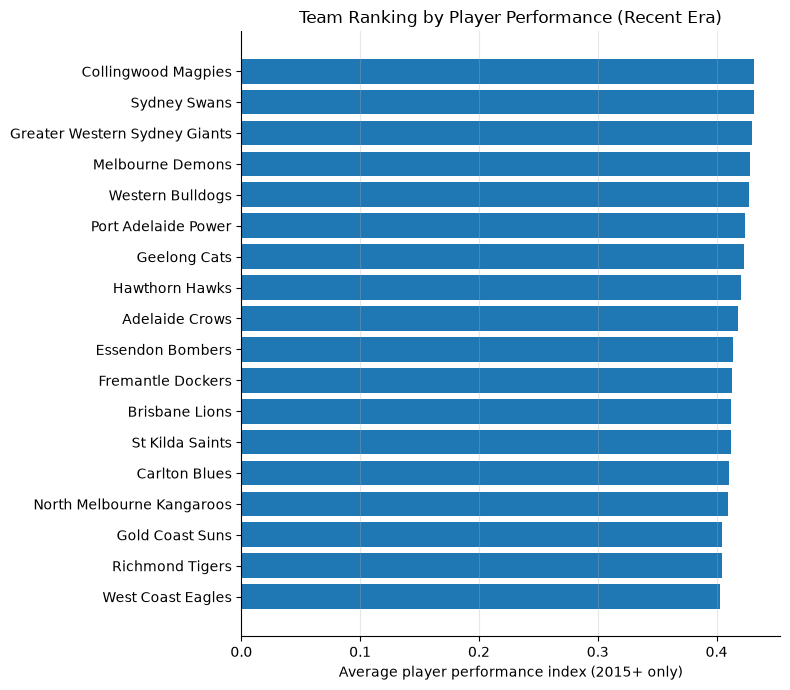

In [61]:
recent = round_df[round_df["year"] >= 2015]
recent_perf = recent.merge(player_stats[["performance_index"]], on="player_id")
team_perf_recent = recent_perf.groupby("team")["performance_index"].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(team_perf_recent.index, team_perf_recent.values)
ax.set_xlabel("Average player performance index (2015+ only)")
ax.set_title("Team Ranking by Player Performance (Recent Era)")
plt.tight_layout()
plt.show()


**Business Insights**:
- ok, so firstly, this stat depends on recency and doesn't necessarily perfectly prove that xyz team is best. GWS and Gold Coast topped the chart before but their entire history is newer than the rest.
- after I put it to 2015 and onwards, Collingwooud Magpies topped the chart, which means that the best talent pool to recruit from is the Collingwood Magpies (if my performance index is trustworthy then obv)
- look at chart 2 and see how the Gold Coast Suns went way down from second position, this is because the comparison is now much more fair across the exact same time span so its makes more sense now

---

## 5. Feature Engineering
   1. Create at least 5 new meaningful features (eg: goals/games, fantasy/games, disposals efficiency)
   2. explain why each new feature you engineered is useful


- ok, we will make 5 simple features
  1. disposal efficiency, just divide total_contested with total_disposals. so basically how much the player won the ball while contested, this could have been part of my original performance_index
  2. fantasy per disposal can be found using avg fantasy points divided by avg disposals, so like, how many fantasy points you get for a disposal
  3. we can do total tackles divide total disposals to find tackle to disposal ratio, as in how defensive a player is compared to how many times he gets the ball
  4. goal involvement per game can be found by simply adding total goals to total goal assists divide games. so like, goals+goalAssists, so we credit the players who setup the goal too
  5. score impact per game, we can just use the official formula of goals * 6 + behinds to get the total score. so how many real scoreboard points is this player personally responsible for per game

In [62]:
totals = round_df.groupby("player_id").agg(
    total_contested=("contested_possessions", "sum"),
    total_disposals=("disposals", "sum"),
    total_tackles=("tackles", "sum"),
    total_goals=("goals", "sum"),
    total_behinds=("behinds", "sum"),
    total_goal_assist=("goal_assist", "sum"),
)

player_stats["disposal_efficiency"] = totals["total_contested"] / totals["total_disposals"]
player_stats["fantasy_per_disposal"] = player_stats["avg_fantasy_points"] / player_stats["avg_disposals"]
player_stats["tackle_rate"] = totals["total_tackles"] / totals["total_disposals"]
player_stats["goal_involvement_per_game"] = (totals["total_goals"] + totals["total_goal_assist"]) / player_stats["games"]
player_stats["score_impact_per_game"] = (totals["total_goals"] * 6 + totals["total_behinds"]) / player_stats["games"]


---


## 6. Final Recommendation
   1. Recommend 5 players for recruitment
   2. support every recommendation with data and visual evidence


- ok, this should be simple, the main 3 new metrics we built, performance index, consistency, and improvement, we can combine all 3 to make the recommendation. Weights can be assigned to each column, I suppose performance index is way more important than the other two

In [64]:
recruitable = (
    player_stats
    .join(consistency[["consistency_score"]])
    .join(improvement.rename("trend"))
)
recruitable = recruitable[recruitable["games"] >= 20]

recruitable["recruit_score"] = (
    recruitable["performance_index"].fillna(0) * 0.5
    + recruitable["consistency_score"].fillna(0) * 0.3
    + (recruitable["trend"].fillna(0) > 0).astype(int) * 0.2
)

top5 = recruitable.sort_values("recruit_score", ascending=False).head(5).join(names)
top5[["name", "performance_index", "consistency_score", "trend", "recruit_score"]]


,name,performance_index,consistency_score,trend,recruit_score
player_id,,,,,
44733,Matt Priddis,0.737537,0.892347,19.024892,0.836473
43414,Marcus Bontempelli,0.689152,0.870564,27.554067,0.805745
45112,Adam Treloar,0.674942,0.864748,4.257488,0.796896
45003,Jack Steele,0.694020,0.829336,33.218634,0.795811
43642,Patrick Cripps,0.718242,0.783610,32.962138,0.794204


**Business Insights**:
- Firstly, lets google these 5 dudes and see if my results are any good:

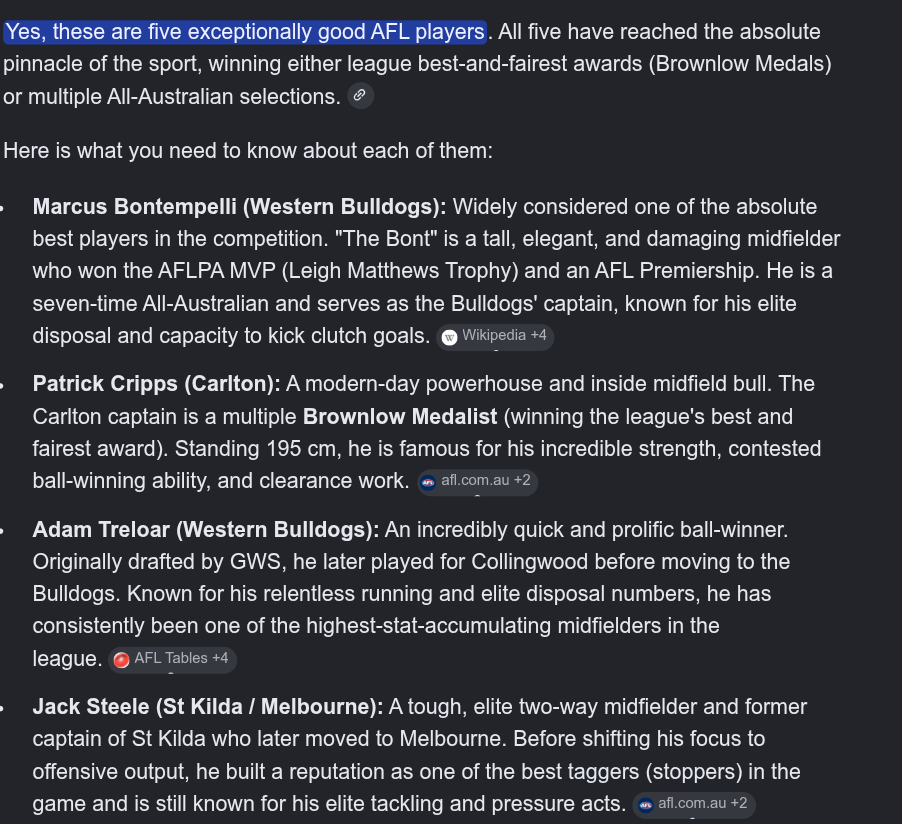

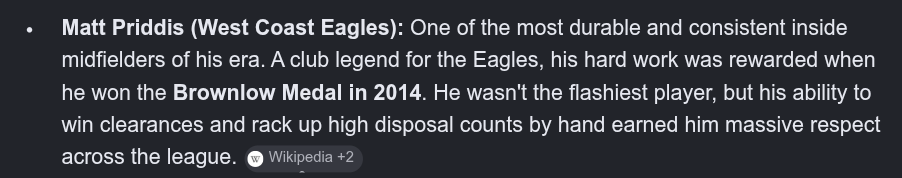

ok, so this is promising, all 5 actually are good players, my metrics are not fully wrong at least

- all 5 of the top players have a positive trend, as in all 5 are improving. Although its obvious that Marcus will probably take the lead from Matt soon (his trend/improvment rate is much higher)

---

#### More Visualizations


- the task demands at least 8 visualizations and I only have 5, so lets make some more quick visualizations and see what they say

lets make a simple consistency to performance index scatter plot

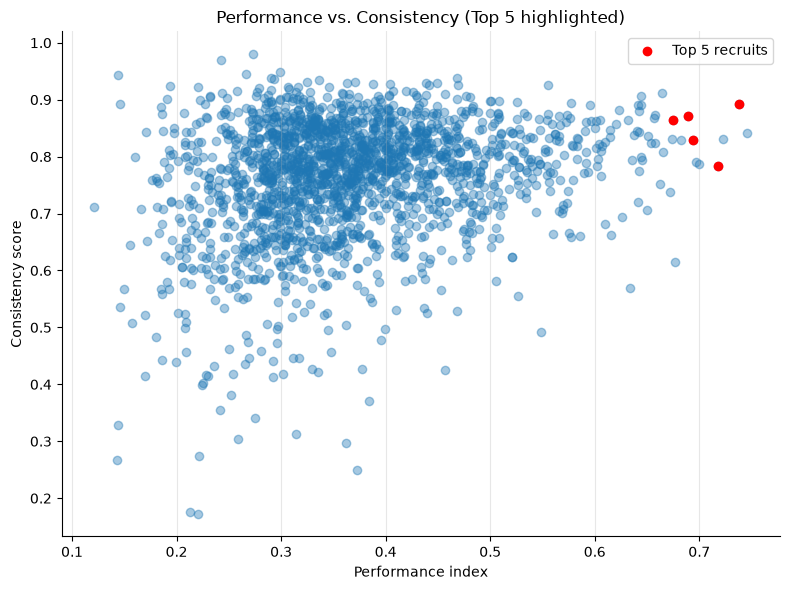

In [65]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(recruitable["performance_index"], recruitable["consistency_score"], alpha=0.4)
ax.scatter(top5["performance_index"], top5["consistency_score"], color="red", label="Top 5 recruits")
ax.set_xlabel("Performance index"); ax.set_ylabel("Consistency score")
ax.set_title("Performance vs. Consistency (Top 5 highlighted)")
ax.legend()
plt.tight_layout(); plt.show()


- the top 5 have high performance index and high consistency, makes perfect sense

---

- we can do a performance index histogram with a vertical line cutting off at the top 10 performance indexes, this will show how rare the top 10 actually are

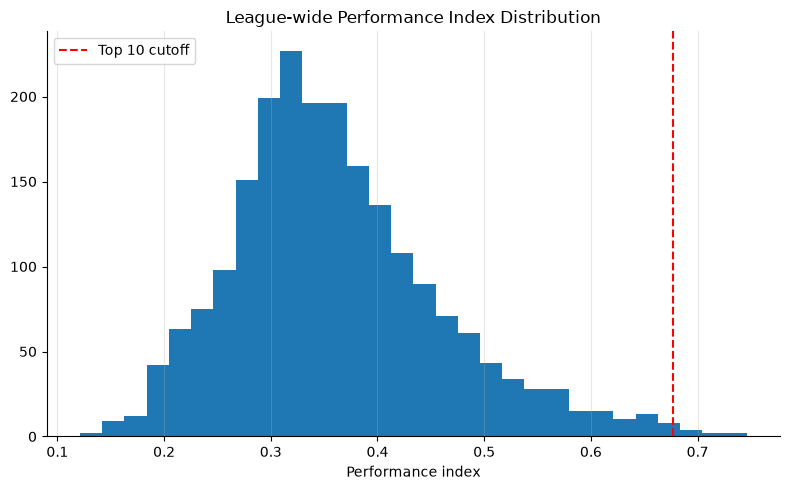

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(player_stats[player_stats["games"]>=20]["performance_index"], bins=30)
ax.axvline(top10["performance_index"].min(), color="red", linestyle="--", label="Top 10 cutoff")
ax.set_xlabel("Performance index"); ax.set_title("Performance Index Distribution")
ax.legend()
plt.tight_layout(); plt.show()


- well, very very rare to say the least, the majority have a performance index around 0.3 to 0.4

---

- We can make another one of those crazy per team boxplot graphs showing how performance index varies across teams

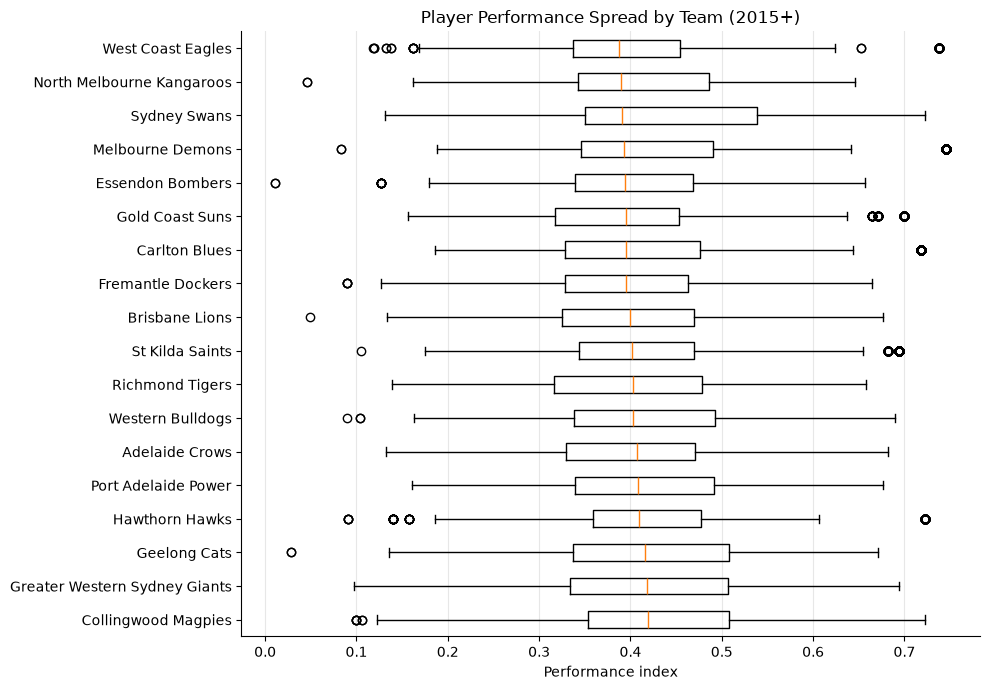

In [70]:
team_order = recent_perf.groupby("team")["performance_index"].median().sort_values(ascending=False).index
data = [recent_perf.loc[recent_perf["team"]==t, "performance_index"] for t in team_order]

fig, ax = plt.subplots(figsize=(10, 7))
ax.boxplot(data, orientation="horizontal", tick_labels=team_order)
ax.set_xlabel("Performance index")
ax.set_title("Player Performance Spread by Team (2015+)")
plt.tight_layout(); plt.show()


## Recommendation Summary

- this is already done in task 6, those are the top 5 recommended players (and checked through google search too)

---